LIBRARIES

In [38]:
#import dataiku

import pandas as pd, numpy as np

#from dataiku import pandasutils as pdu



In [39]:
# -------------------------------------------------------------------------------- NOTEBOOK-CELL: CODE

import statsmodels

import statsmodels.api as sm

import statsmodels.formula.api as smf



In [40]:
# -------------------------------------------------------------------------------- NOTEBOOK-CELL: CODE

import os

import sys

from scipy import stats

import matplotlib.pyplot as plt

import seaborn as sns

# %matplotlib inline

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.linear_model import LinearRegression  # Add this import

# -------------------------------------------------------------------------------- NOTEBOOK-CELL: CODE



In [41]:
from datetime import date

import holidays

from workalendar.europe import France

import datetime


DATA PREPARATION

In [42]:
data = pd.read_csv(r"C:\Users\utilisateur\Downloads\wetransfer_histo_gazpar_merged-3-csv-gz_2026-01-30_1023\histo_gazpar_merged(1).csv.gz")


In [43]:
data.shape

(2797952, 35)

In [44]:
data['pce']=data['pce'].astype(str)


In [45]:

def add_leading_zeros(pce_value):

    if len(pce_value) <= 13:

        # Pad the string with leading zeros to make it 14 characters long

        return pce_value.zfill(14)

    else:

        return pce_value

# Apply the function to the 'pce' column

data['pce'] = data['pce'].apply(add_leading_zeros)


In [46]:
data = data.sort_values(by=['pce', 'gasday'])

data['trend'] = data.groupby('pce').cumcount() + 1

In [47]:
data['gasday'] = pd.to_datetime(data['gasday']).dt.date

# Function to determine if a day is a workday (Mon-Fri) or weekend (Sat-Sun)

def is_workday(date):

   return 1 if date.weekday() < 5 else 0

# Apply the function to create the Workday column

data['workday'] = data['gasday'].apply(is_workday)

data['weekend'] = 1-data['workday']

In [48]:
# ## Add Holidays

# -------------------------------------------------------------------------------- NOTEBOOK-CELL: CODE

# Assuming col 'year'

unique_years = data['year'].unique()

# Convert unique_years to integers and create a list

unique_years_list = unique_years.astype(int).tolist()

# Create an empty dictionary to store the holidays for each year

fr_holidays = {}

# Iterate through unique years and get the public holidays for each year

for year in unique_years_list:

    fr_holidays[year] = holidays.France(years=[year])

# Flatten the holiday dictionary for easier lookup

all_holidays = {date: name for year in fr_holidays for date, name in fr_holidays[year].items()}

all_holidays


# Create a new column indicating whether each date is a public holiday (1 or 0)

data['Is_Public_Holiday'] = data['gasday'].apply(lambda x: 1 if x in all_holidays else 0)

# Create a column with the holiday name or an empty string if it is not a holiday

data['Holiday_Name'] = data['gasday'].apply(lambda x: all_holidays.get(x, ''))


In [49]:
# Determine if it's a non-working day

data['non_working_day'] = data['weekend'] | data['Is_Public_Holiday']


In [50]:
# Count observations per category

data['count'] = data.groupby('pce')['pce'].transform('count')

In [51]:
# Check for missing values and drop rows with missing values

data_nona = data.dropna(subset=['valeur_energie_conso', 'hdd', 'trend', 'pce'])


In [ ]:
# =========================
# Pré-nettoyage minimal
# =========================
datanona = data.dropna(subset=["valeurenergieconso", "hdd", "trend", "pce"]).copy()

# Optionnel mais recommandé : garder uniquement des types propres
datanona["pce"] = datanona["pce"].astype(str)

# =========================
# 1) Premier modèle
# =========================
modellmm = smf.mixedlm(
    "valeurenergieconso ~ hdd + trend + IsPublicHoliday",
    data=datanona,
    groups=datanona["pce"],
    re_formula="hdd + 1"
)

resultlmm = modellmm.fit(method="lbfgs", maxiter=600)

# =========================
# 2) Effets aléatoires par PCE
# =========================
redf = pd.DataFrame.from_dict(resultlmm.random_effects, orient="index")
redf.index.name = "pce"
redf = redf.reset_index()

# Renommage robuste
cols = list(redf.columns)
if len(cols) >= 3:
    redf = redf.rename(columns={
        cols[1]: "randintercept",
        cols[2]: "randslope"
    })
elif len(cols) == 2:
    redf = redf.rename(columns={cols[1]: "randintercept"})
    redf["randslope"] = 0.0

fixed_intercept = resultlmm.fe_params["Intercept"]
fixed_slope_hdd = resultlmm.fe_params["hdd"]

datanona = datanona.merge(redf[["pce", "randintercept", "randslope"]], on="pce", how="left")

datanona["randintercept"] = datanona["randintercept"].fillna(0)
datanona["randslope"] = datanona["randslope"].fillna(0)

datanona["interceptclient"] = fixed_intercept + datanona["randintercept"]
datanona["penteclient"] = fixed_slope_hdd + datanona["randslope"]

# Partie fixe supplémentaire si présente dans le modèle
datanona["consopredite"] = (
    datanona["interceptclient"]
    + datanona["penteclient"] * datanona["hdd"]
    + resultlmm.fe_params.get("trend", 0) * datanona["trend"]
    + resultlmm.fe_params.get("IsPublicHoliday", 0) * datanona.get("IsPublicHoliday", 0)
)

datanona["consoresidu"] = datanona["valeurenergieconso"] - datanona["consopredite"]

# =========================
# 3) Suppression des outliers sur résidu uniquement
# =========================
def remove_outliers_on_residuals(group, col="consoresidu", factor=1.5):
    q1 = group[col].quantile(0.25)
    q3 = group[col].quantile(0.75)
    iqr = q3 - q1

    if pd.isna(iqr) or iqr == 0:
        return group

    lower = q1 - factor * iqr
    upper = q3 + factor * iqr
    return group[group[col].between(lower, upper)]

datanona = (
    datanona
    .groupby("pce", group_keys=False)
    .apply(remove_outliers_on_residuals)
    .reset_index(drop=True)
)

# =========================
# 4) Nettoyage final
# =========================
cols_to_drop = [
    "randintercept", "randslope",
    "interceptclient", "penteclient",
    "consopredite", "consoresidu"
]
datanona = datanona.drop(columns=[c for c in cols_to_drop if c in datanona.columns])

# Dataset final propre pour la suite
data_clean = datanona.copy()

C:\Users\utilisateur\AppData\Local\Temp\ipykernel_45548\4129039634.py:53: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_f)


n_rows                2382167.0
n_groups                 7305.0
missing_target_pct          0.0
missing_hdd_pct             0.0
dtype: float64

,pce,valeurenergieconso,hdd,trend
0,22114761187602,5.0,0.0,1
1,22114761187602,4.0,0.0,2
2,22114761187602,8.0,0.0,3
3,22114761187602,4.0,0.0,4
4,22114761187602,7.0,0.0,5


In [16]:
# Subset the dataset where column 'is_outlier' is not equal to -1

# data_nona = data_nona[data_nona['is_outlier'] != -1]

# data_nona.shape

data_nona = data_nona[(data_nona['hdd'] != 0) & (data['valeur_energie_conso'] != 0)]

In [77]:
# FE weights are related to overall residual variance (Captures "leftover" variability within groups after accounting for both fixed and random effects), RE varince (Captures how much group-specific deviations (random effects) vary around the population average (fixed effects).the RE variance-covariance matrix is used to weight the FE estimates and their uncertainty. The FE estimates are derived by "pooling" group-specific effects, with pooling weights determined by:

# The relative magnitude of within-group vs. between-group variance,

# Correlations between random effects (e.g., intercept-slope covariance).

# -------------------------------------------------------------------------------- NOTEBOOK-CELL: MARKDOWN

# ## Models

In [78]:
#%%time

lmm_default = smf.mixedlm(

    formula='valeur_energie_conso ~ hdd + trend + Is_Public_Holiday',

    data=data_nona,

    groups="pce",

    re_formula="~hdd + 1"

).fit(method=["lbfgs"], maxiter=600)

lmm_default.summary()



c:\Users\utilisateur\Desktop\programmation\Statap\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
              Mixed Linear Model Regression Results
==================================================================
Model:            MixedLM Dependent Variable: valeur_energie_conso
No. Observations: 2797952 Method:             REML                
No. Groups:       8074    Scale:              3819891.5806        
Min. group size:  1       Log-Likelihood:     -25172951.0203      
Max. group size:  473     Converged:          Yes                 
Mean group size:  346.5                                           
------------------------------------------------------------------
                      Coef.   Std.Err.   z    P>|z|  [0.025 0.975]
------------------------------------------------------------------
Intercept              10.460    2.316  4.516 0.000   5.920 14.999
hdd                     5.339    0.264 20.203 0.000   4.821  5.857
trend                   0.004    0.009  0.418 0.676  -0.014  0.021
Is_Public_Holiday      -4.707    6.565 -0.717 0.473 -17.574  8.160
pce Var              1348.814    0.173                            
pce x hdd Cov        -197.497    0.092                            
hdd Var                29.607    0.016                            
==================================================================

"""

In [79]:
df_random_effects_default = pd.DataFrame.from_dict(lmm_default.random_effects, orient='index')


In [81]:
# Add fixed effects to the DataFrame

df_random_effects_default['Fixed intercept'] = lmm_default.fe_params.loc['Intercept']

df_random_effects_default['Fixed slope trend'] = lmm_default.fe_params.loc['trend']

df_random_effects_default['Fixed slope Is_Public_Holiday'] = lmm_default.fe_params.loc['Is_Public_Holiday']

df_random_effects_default['Fixed slope hdd'] = lmm_default.fe_params.loc['hdd']

In [82]:
# Rename columns for clarity

df_random_effects_default = df_random_effects_default.rename({

    'pce': 'Random intercept',

    'hdd': 'Random slope hdd'

}, axis=1)


In [83]:
# Calculate the combined (fixed + random) effects

df_random_effects_default['INTERCEPT LMM'] = df_random_effects_default['Random intercept'] + df_random_effects_default['Fixed intercept']

df_random_effects_default['SLOPE LMM hdd'] = df_random_effects_default['Random slope hdd'] + df_random_effects_default['Fixed slope hdd']

In [84]:
# delete id needed

df_random_effects = df_random_effects_default


In [85]:
df_random_effects = df_random_effects.reset_index().rename(columns={'index': 'pce'})


In [86]:
df_random_effects

,pce,Random intercept,Random slope hdd,Fixed intercept,Fixed slope trend,Fixed slope Is_Public_Holiday,Fixed slope hdd,INTERCEPT LMM,SLOPE LMM hdd
0,22114761187602,-1.221629,0.190158,10.459542,0.003768,-4.706619,5.338617,9.237912,5.528775
1,22114761188829,-0.425460,0.083189,10.459542,0.003768,-4.706619,5.338617,10.034081,5.421806
2,22114761191548,-0.595924,0.080927,10.459542,0.003768,-4.706619,5.338617,9.863618,5.419544
3,22114761192886,-0.427303,0.063230,10.459542,0.003768,-4.706619,5.338617,10.032238,5.401847
4,22114761202808,-0.486525,0.075685,10.459542,0.003768,-4.706619,5.338617,9.973017,5.414302
...,...,...,...,...,...,...,...,...,...
8069,22157452873546,-0.540610,0.078490,10.459542,0.003768,-4.706619,5.338617,9.918931,5.417107
8070,22157452876350,-0.422328,0.056529,10.459542,0.003768,-4.706619,5.338617,10.037214,5.395146
8071,22157452887265,-2.059600,0.320327,10.459542,0.003768,-4.706619,5.338617,8.399942,5.658944
8072,22157452890759,-0.451836,0.066194,10.459542,0.003768,-4.706619,5.338617,10.007705,5.404812


In [27]:
merged_df = df_random_effects


In [28]:
data_nona_unique = data_nona[['pce', 'count']].drop_duplicates(subset='pce')


In [29]:
# Convert 'pce' column in both DataFrames to string

merged_df['pce'] = merged_df['pce'].astype(str)

data_nona_unique['pce'] = data_nona_unique['pce'].astype(str)

merged_df=pd.merge(merged_df, data_nona_unique[['pce', 'count']], on='pce', how='left')


In [70]:
merged_df


,pce,Random intercept,Random slope hdd,Fixed intercept,Fixed slope trend,Fixed slope Is_Public_Holiday,Fixed slope hdd,INTERCEPT LMM,SLOPE LMM hdd,count
0,22114761187602,0.846170,3.604619,6.785664,0.001592,-2.497294,5.874167,7.631833,9.478786,466
1,22114761188829,42.736706,7.986923,6.785664,0.001592,-2.497294,5.874167,49.522369,13.861090,290
2,22114761191548,-9.183502,-2.020182,6.785664,0.001592,-2.497294,5.874167,-2.397839,3.853985,445
3,22114761192886,-1.876972,0.285497,6.785664,0.001592,-2.497294,5.874167,4.908692,6.159664,358
4,22114761202808,9.758131,0.449151,6.785664,0.001592,-2.497294,5.874167,16.543794,6.323318,470
...,...,...,...,...,...,...,...,...,...,...
7422,22157452873546,-14.007026,0.979785,6.785664,0.001592,-2.497294,5.874167,-7.221362,6.853952,266
7423,22157452876350,-6.747869,-1.172015,6.785664,0.001592,-2.497294,5.874167,0.037795,4.702152,470
7424,22157452887265,-9.624720,7.339599,6.785664,0.001592,-2.497294,5.874167,-2.839056,13.213766,451
7425,22157452890759,-14.459331,1.028546,6.785664,0.001592,-2.497294,5.874167,-7.673668,6.902713,225


In [72]:
df_results = data_nona_unique.copy()
df_results = df_results.merge(merged_df, on='pce', how='left')


In [73]:

# Calcul de la Consommation Normalisée (On retire l'effet météo spécifique à ce client pour ne garder que le comportement : Conso_Norm = Conso_Reelle - (Sensibilité_Client * Météo)
df_results['conso_corr'] = df_results['valeur_energie_conso'] - df_results['SLOPE LMM hdd'] * (df_results['hdd'] - df_results["hdd_ref"])

KeyError: 'valeur_energie_conso'

[]

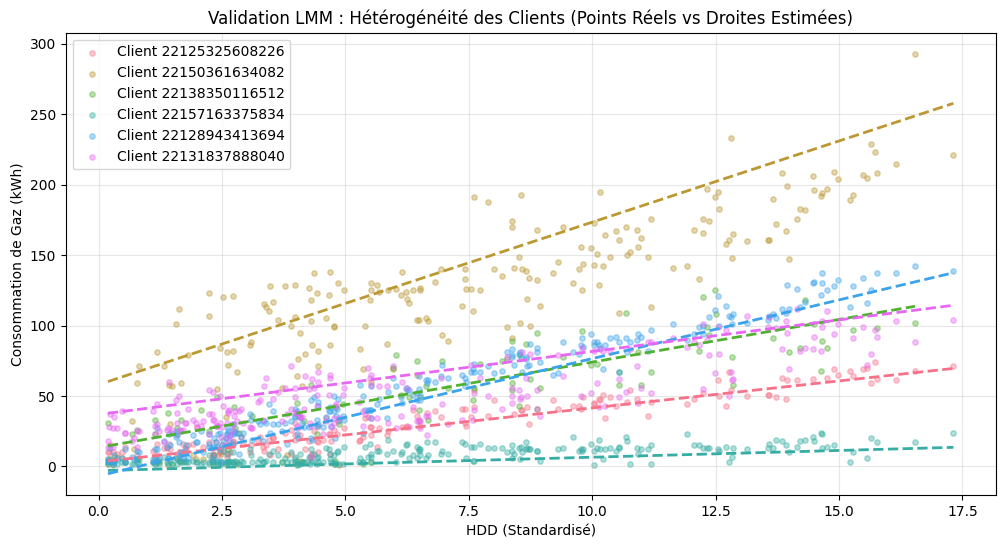

In [57]:
# Objectif : Montrer que chaque client réagit différemment au froid (Pentes aléatoires)

# Sélection de 6 clients aléatoires
sample_pces = np.random.choice(df_results['pce'].unique(), 6, replace=False)
subset_plot = df_results[df_results['pce'].isin(sample_pces)].copy()

plt.figure(figsize=(12, 6))

# Palette de couleurs pour distinguer les clients
colors = sns.color_palette("husl", len(sample_pces))

for i, pce in enumerate(sample_pces):
    pce_data = subset_plot[subset_plot['pce'] == pce]
    color = colors[i]
    
    # Nuage de points
    plt.scatter(pce_data['hdd'], pce_data['valeur_energie_conso'], 
                alpha=0.4, s=15, color=color, label=f"Client {pce}")
    
    # Droite du Modèle LMM (Pente spécifique à ce client)
    # y = (Intercept_Fixe + Intercept_Random) + (Pente_Fixe + Pente_Random) * X
    intercept_fixed = pce_data['INTERCEPT LMM'].iloc[0]
    intercept_total = intercept_fixed + pce_data['Random intercept'].iloc[0]
    slope_total = pce_data['SLOPE LMM hdd'].iloc[0]
    
    # Création de la ligne de régression
    x_vals = np.array([pce_data['hdd'].min(), pce_data['hdd'].max()])
    y_vals = intercept_total + slope_total * x_vals
    
    plt.plot(x_vals, y_vals, color=color, linewidth=2, linestyle='--')

plt.title("Validation LMM : Hétérogénéité des Clients (Points Réels vs Droites Estimées)")
plt.xlabel("HDD (Standardisé)")
plt.ylabel("Consommation de Gaz (kWh)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.plot()

In [ ]:
plt.plot(df_results.groupby("date_parsed")["conso_corr"].sum())

0            3.210077
1            1.210029
2          -16.606917
3          -19.627634
4          -21.193166
              ...    
1419338    181.096228
1419339    162.597037
1419340    182.147852
1419341    172.239504
1419342    149.022879
Name: conso_corr, Length: 1419343, dtype: float64

Nb PCE panel équilibré : 4628
Période : 2024 - 2026


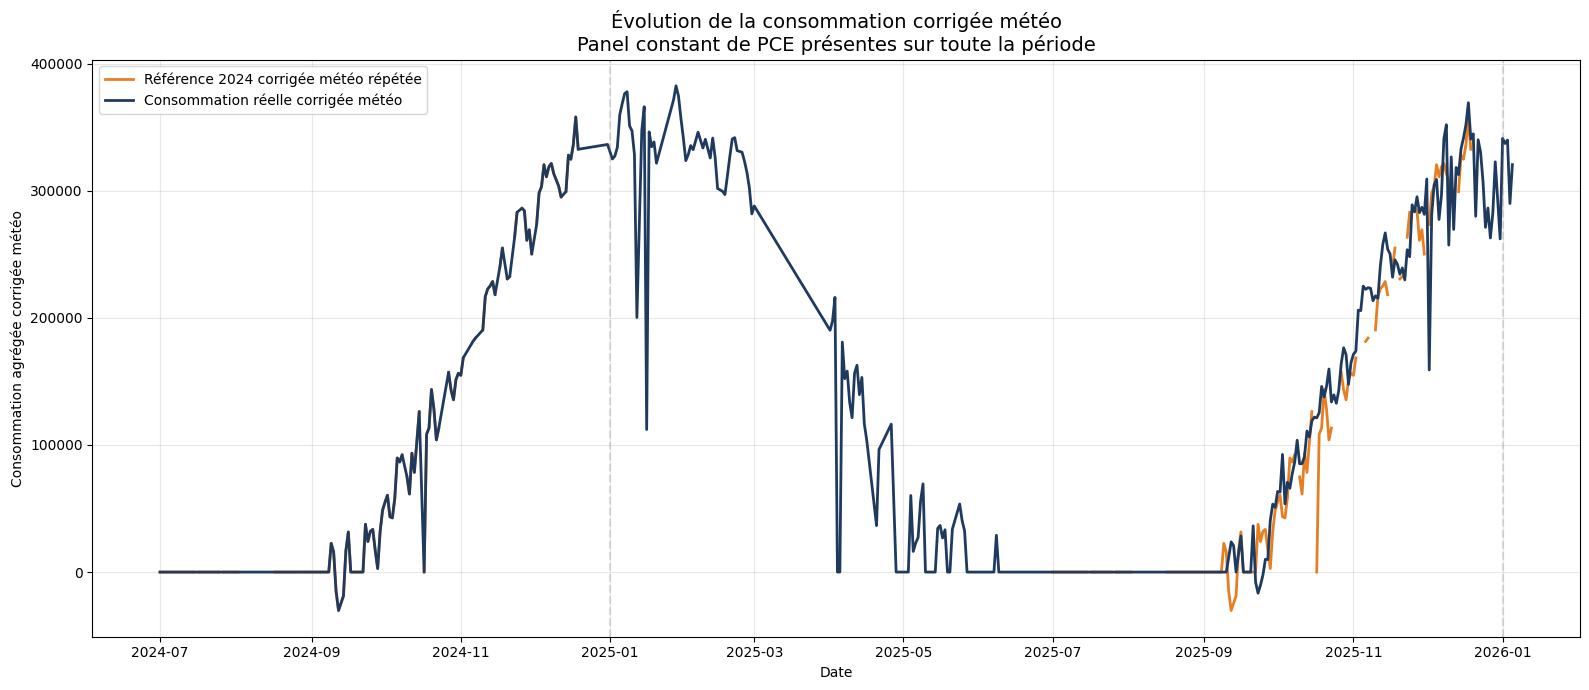

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 0) Base de travail
# =========================
df_plot = df_results.copy()

# Harmonisation des noms
if "consocorr" in df_plot.columns and "conso_corr" not in df_plot.columns:
    df_plot = df_plot.rename(columns={"consocorr": "conso_corr"})

# Si la colonne n'existe pas encore, on la recalcule
if "conso_corr" not in df_plot.columns:
    df_plot["conso_corr"] = (
        df_plot["valeurenergieconso"]
        - df_plot["SLOPE LMM hdd"] * (df_plot["hdd"] - df_plot["hdd_ref"])
    )

# Dates / année
df_plot["date_parsed"] = pd.to_datetime(df_plot["date_parsed"])
df_plot["year"] = df_plot["date_parsed"].dt.year
df_plot["month"] = df_plot["date_parsed"].dt.month
df_plot["day"] = df_plot["date_parsed"].dt.day

# On retire le 29 février pour pouvoir répéter la même année sur toutes les années
df_plot = df_plot[~((df_plot["month"] == 2) & (df_plot["day"] == 29))].copy()

# =========================
# 1) Sélection des PCE présentes du début à la fin
# =========================
min_year = df_plot["year"].min()
max_year = df_plot["year"].max()
all_years = set(range(min_year, max_year + 1))

pce_years = df_plot.groupby("pce")["year"].agg(lambda x: set(x)).reset_index(name="years_present")
pce_full_period = pce_years.loc[
    pce_years["years_present"].apply(lambda s: all_years.issubset(s)),
    "pce"
]

df_balanced = df_plot[df_plot["pce"].isin(pce_full_period)].copy()

print("Nb PCE panel équilibré :", df_balanced["pce"].nunique())
print("Période :", min_year, "-", max_year)

# =========================
# 2) Courbe réelle corrigée météo
# =========================
daily_real_corr = (
    df_balanced.groupby("date_parsed", as_index=True)["conso_corr"]
    .sum()
    .sort_index()
)

# =========================
# 3) Profil année 1 corrigé météo, répété chaque année
# =========================
# Année de référence = première année de la période
df_ref = df_balanced[df_balanced["year"] == min_year].copy()

# Profil journalier année 1 par mois-jour
ref_profile = (
    df_ref.groupby(["month", "day"], as_index=False)["conso_corr"]
    .sum()
    .rename(columns={"conso_corr": "conso_corr_ref_annee1"})
)

# Calendrier complet de la période, sans 29/02
full_calendar = pd.DataFrame({
    "date_parsed": pd.date_range(
        start=df_balanced["date_parsed"].min(),
        end=df_balanced["date_parsed"].max(),
        freq="D"
    )
})

full_calendar["year"] = full_calendar["date_parsed"].dt.year
full_calendar["month"] = full_calendar["date_parsed"].dt.month
full_calendar["day"] = full_calendar["date_parsed"].dt.day

full_calendar = full_calendar[
    ~((full_calendar["month"] == 2) & (full_calendar["day"] == 29))
].copy()

# Répétition du profil année 1 sur tout le calendrier
full_calendar = full_calendar.merge(
    ref_profile,
    on=["month", "day"],
    how="left"
)

baseline_repeated = (
    full_calendar.set_index("date_parsed")["conso_corr_ref_annee1"]
    .sort_index()
)

# =========================
# 5) Graphique final
# =========================
plt.figure(figsize=(16, 7))

plt.plot(
    baseline_repeated.index,
    baseline_repeated.values,
    label=f"Référence {min_year} corrigée météo répétée",
    color="#E67E22",
    linewidth=2
)

plt.plot(
    daily_real_corr.index,
    daily_real_corr.values,
    label="Consommation réelle corrigée météo",
    color="#1F3A5F",
    linewidth=2
)

# séparation visuelle des années
for y in range(min_year + 1, max_year + 1):
    plt.axvline(pd.Timestamp(f"{y}-01-01"), color="grey", linestyle="--", alpha=0.25)

plt.title("Évolution de la consommation corrigée météo\nPanel constant de PCE présentes sur toute la période", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Consommation agrégée corrigée météo")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [67]:
df_results["hdd_ref"]=df_results["hdd"]